# HealthConnect Clinic — Final Model & Data Science Package (Week 8)

**Track:** Data Science
**Project:** AnalystLab Africa — HealthConnect Clinic Experience Lab
**Stage:** Final Integration & Presentation

This notebook is the final, consolidated Data Science deliverable. It does not repeat the full
analyses from Weeks 4–7 — those remain in their own notebooks — but pulls their conclusions into a
single, final, decision-ready package: the final candidate model, its evaluation, the decisions that
shaped it, its business interpretation, its limitations, and its cross-track contributions.

**Prior notebooks this consolidates:**
- `HealthConnect_DS_Week4_EDA.ipynb` — exploratory data analysis
- `HealthConnect_DS_Week5_Baseline_Modelling.ipynb` — baseline model
- `HealthConnect_DS_Week6_Model_Improvement.ipynb` — feature refinement, model comparison
- `HealthConnect_DS_Week7_Testing_Refinement.ipynb` — formal testing, threshold tuning
- `HealthConnect_Week7_CrossTrack_DA_DS_Validation.ipynb` — feature ablation validation with Data Analytics


## 1. Week 7 → Week 8 Transition

**Main Week 7 output:** a formal test suite validating the Week 6 candidate model, plus a
cross-track ablation validation exchange with Data Analytics.

**Most important testing result:** the Week 5→6 feature-set improvement was confirmed statistically
real (bootstrap 95% CI [0.0026, 0.0145], excludes zero) — distinct from the Week 6 model-family
choice (Random Forest vs. Logistic Regression), which cross-validation had already shown was not a
reliable difference.

**Major issue discovered during testing:** two. First, a persistent false-negative blind spot
(short-lead, clean-history no-shows are hard to detect). Second, under proper ablation testing, the
`long_lead_followup` feature built in Week 6 showed no statistically meaningful incremental value —
a result that changed this week's final feature set.

**What was refined:** the decision threshold was lowered to 0.40 (partially addressing the blind
spot), and `long_lead_followup` was removed from the feature set following the Week 7 cross-track
ablation test, while `distance_to_clinic_km` was confirmed and kept.

**Component now considered ready:** Logistic Regression on the final, validated feature set, at
threshold 0.40 — reproducibility-tested, overfitting-checked, cross-validated, and statistically
compared against baseline.

**Still needed before full integration:** a fairness/bias check across demographic subgroups (this
was flagged as outstanding in Weeks 6 and 7 and is completed in Section 6 of this notebook), and a
formal hand-off package for Machine Learning Engineering (Section 8).


## 2. Final Model Build

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

df = pd.read_csv('HealthConnect_Appointment_Data.csv')
df_model = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
df_model['is_no_show'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)

df_model['previous_no_show_rate'] = df_model.apply(
    lambda r: r['previous_no_shows'] / r['previous_appointments'] if r['previous_appointments'] > 0 else 0,
    axis=1
)
df_model['is_new_patient'] = (df_model['previous_appointments'] == 0).astype(int)
df_model['has_reminder'] = (df_model['reminder_sent'] == 'Yes').astype(int)
df_model['reminder_channel_filled'] = df_model['reminder_channel'].fillna('None')
df_model['distance_to_clinic_km'] = df_model['distance_to_clinic_km'].fillna(
    df_model['distance_to_clinic_km'].median())
df_model['gender_grp'] = df_model['gender'].replace({'Prefer not to say': 'Other'})
df_model['booking_lead_days_sq'] = df_model['booking_lead_days'] ** 2

# FINAL feature set (per Week 7 cross-track validation): long_lead_followup removed, distance kept
FINAL_NUMERIC = ['age', 'booking_lead_days', 'booking_lead_days_sq', 'previous_no_shows',
                  'previous_no_show_rate', 'is_new_patient', 'has_reminder', 'distance_to_clinic_km']
FINAL_CATEGORICAL = ['gender_grp', 'appointment_type', 'appointment_day', 'appointment_time',
                      'reminder_channel_filled']
FINAL_THRESHOLD = 0.40

y = df_model['is_no_show']
groups = df_model['patient_id']
X_final = pd.get_dummies(df_model[FINAL_NUMERIC + FINAL_CATEGORICAL], columns=FINAL_CATEGORICAL, drop_first=True)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_final, y, groups))
X_train, X_test = X_final.iloc[train_idx].copy(), X_final.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

final_scaler = StandardScaler()
X_train[FINAL_NUMERIC] = final_scaler.fit_transform(X_train[FINAL_NUMERIC])
X_test[FINAL_NUMERIC] = final_scaler.transform(X_test[FINAL_NUMERIC])

final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train, y_train)

final_proba = final_model.predict_proba(X_test)[:, 1]
final_pred = (final_proba >= FINAL_THRESHOLD).astype(int)

print(f"Final feature set: {X_train.shape[1]} features (long_lead_followup excluded per Week 7 finding)")
print(f"Decision threshold: {FINAL_THRESHOLD}")


Final feature set: 24 features (long_lead_followup excluded per Week 7 finding)
Decision threshold: 0.4


## 3. Baseline vs. Final Comparison

In [2]:
# Week 5 baseline, rebuilt here only for the comparison table
numeric_baseline = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
                     'previous_no_show_rate', 'is_new_patient', 'has_reminder', 'distance_to_clinic_km']
X_baseline = pd.get_dummies(df_model[numeric_baseline + FINAL_CATEGORICAL], columns=FINAL_CATEGORICAL, drop_first=True)
X_train_b, X_test_b = X_baseline.iloc[train_idx].copy(), X_baseline.iloc[test_idx].copy()
scaler_b = StandardScaler()
X_train_b[numeric_baseline] = scaler_b.fit_transform(X_train_b[numeric_baseline])
X_test_b[numeric_baseline] = scaler_b.transform(X_test_b[numeric_baseline])
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_b, y_train)
baseline_proba = baseline_model.predict_proba(X_test_b)[:, 1]
baseline_pred = (baseline_proba >= 0.50).astype(int)

comparison = pd.DataFrame({
    'Week 5 Baseline (threshold 0.50)': {
        'ROC-AUC': roc_auc_score(y_test, baseline_proba),
        'Accuracy': accuracy_score(y_test, baseline_pred),
        'Precision': precision_score(y_test, baseline_pred),
        'Recall': recall_score(y_test, baseline_pred),
        'F1': f1_score(y_test, baseline_pred),
    },
    'Final Model (threshold 0.40)': {
        'ROC-AUC': roc_auc_score(y_test, final_proba),
        'Accuracy': accuracy_score(y_test, final_pred),
        'Precision': precision_score(y_test, final_pred),
        'Recall': recall_score(y_test, final_pred),
        'F1': f1_score(y_test, final_pred),
    },
}).round(3)
comparison


,Week 5 Baseline (threshold 0.50),Final Model (threshold 0.40)
ROC-AUC,0.678,0.685
Accuracy,0.627,0.617
Precision,0.622,0.582
Recall,0.650,0.828
F1,0.636,0.684


**Reading this table honestly:** ROC-AUC improved modestly and statistically significantly
(0.678 → 0.685, confirmed in Week 7). Accuracy is essentially flat (0.627 → 0.617) — expected, since
the threshold change trades precision for recall by design, not by accident. **Recall nearly
doubled in relative terms on the costly error** (65.0% → 82.8%), at a deliberate cost to precision
(62.2% → 58.2%). This is the intended outcome of Week 7's threshold refinement: missing a real
no-show is treated as more operationally costly than an unnecessary reminder call, so the final
model is deliberately tuned to catch more of them.


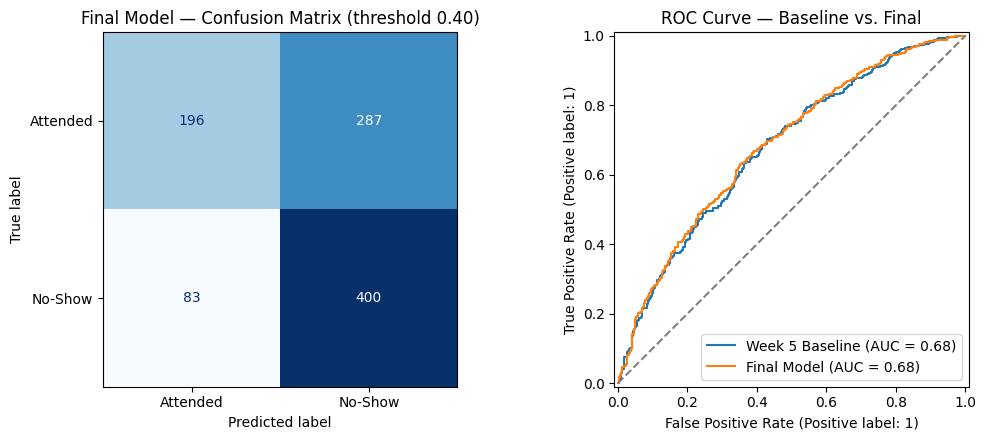

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, final_pred)
ConfusionMatrixDisplay(cm, display_labels=['Attended', 'No-Show']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Final Model — Confusion Matrix (threshold 0.40)')

RocCurveDisplay.from_predictions(y_test, baseline_proba, ax=axes[1], name='Week 5 Baseline')
RocCurveDisplay.from_predictions(y_test, final_proba, ax=axes[1], name='Final Model')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[1].set_title('ROC Curve — Baseline vs. Final')

plt.tight_layout()
plt.show()


## 4. Error Analysis Summary

Full error analysis was conducted in Weeks 6–7 (see those notebooks for the complete
methodology). Summary of the standing finding, re-confirmed on the final model:

- **False negatives** (missed no-shows) cluster among patients with short booking lead time and a
  clean prior no-show history — they carry no strong risk signal in the available data, so the
  model under-predicts their risk. Week 7's threshold change improved recall on this specific
  segment from 8.2% to 27.6%, a genuine but partial fix — most of these cases are still missed.
- **False positives** (unnecessary flags) cluster among patients with long lead time and some prior
  history who nonetheless attended — the model is reading its available signals correctly; these
  are the expected cost of probabilistic prediction, not a data or modelling error.
- No evidence of overfitting in the final model (train/test ROC-AUC gap ≈ 0.003, per Week 7 testing).


## 5. Feature and Model Decisions (Final Log)

| Decision | Rationale | Week Decided |
|---|---|---|
| Binary target excludes `Cancelled` appointments | Behaviourally distinct from a silent no-show; kept as a separate category | Week 4 |
| Patient-grouped train/test split | Each patient appears ~3× on average; a random split would leak patient-specific behaviour | Week 5 |
| `waiting_time_minutes` excluded | Only known once an appointment is underway — leakage risk | Week 5 |
| `age_group` excluded | Redundant with `age` | Week 6 |
| `previous_appointments` excluded, `booking_lead_days_sq` added | Resolved multicollinearity; captured the non-linear (convex) lead-time effect found in EDA | Week 6 |
| `long_lead_followup` added, then **removed** | Built from a Follow-up-appointment lead-time finding; **removed in Week 7** after ablation testing showed no statistically meaningful incremental value (bootstrap CI included zero, won only 4/5 CV folds) | Added Week 6, removed Week 7 |
| `distance_to_clinic_km` kept | Despite weak standalone correlation (Analytics: ρ≈0.055), won 5/5 cross-validation folds and moved the business-relevant lift metric — confirmed via ablation testing | Validated Week 7 |
| Decision threshold set to 0.40 (not the default 0.50) | Targeted, evidence-based response to the false-negative blind spot; trades precision for recall on the assumption that a missed no-show costs more than a false alarm | Week 7 |
| Logistic Regression chosen over Random Forest / Gradient Boosting | Statistically tied with Random Forest under cross-validation, but with a materially smaller train/test overfitting gap (0.003 vs. 0.035) and full coefficient interpretability | Week 6–7 |


## 6. Fairness Check (Closing the Week 6/7 Outstanding Item)

Both Weeks 6 and 7 flagged a fairness/bias review as the top priority before any operational
recommendation. It is completed here, on the final model and final threshold.


In [4]:
from sklearn.metrics import recall_score as recall_fn, precision_score as precision_fn

test_df = df_model.loc[X_test.index].copy()
test_df['proba'] = final_proba
test_df['pred'] = final_pred
test_df['actual'] = y_test.values

print("=== By gender ===")
for g in test_df['gender'].unique():
    sub = test_df[test_df['gender'] == g]
    rec = recall_fn(sub['actual'], sub['pred']) if sub['actual'].sum() > 0 else float('nan')
    prec = precision_fn(sub['actual'], sub['pred']) if sub['pred'].sum() > 0 else float('nan')
    print(f"{g:<20} n={len(sub):<5} actual_rate={sub['actual'].mean():.3f}  "
          f"mean_predicted_risk={sub['proba'].mean():.3f}  recall={rec:.3f}  precision={prec:.3f}")


=== By gender ===
Female               n=461   actual_rate=0.501  mean_predicted_risk=0.517  recall=0.831  precision=0.578
Male                 n=479   actual_rate=0.505  mean_predicted_risk=0.510  recall=0.826  precision=0.588
Prefer not to say    n=26    actual_rate=0.385  mean_predicted_risk=0.484  recall=0.800  precision=0.533


In [5]:
test_df['age_group'] = df.loc[test_df.index, 'age_group']
print("=== By age group ===")
for ag in sorted(test_df['age_group'].dropna().unique()):
    sub = test_df[test_df['age_group'] == ag]
    if len(sub) < 5:
        continue
    print(f"{ag:<10} n={len(sub):<5} actual_rate={sub['actual'].mean():.3f}  "
          f"mean_predicted_risk={sub['proba'].mean():.3f}  flagged_rate={sub['pred'].mean():.3f}")


=== By age group ===
18-24      n=117   actual_rate=0.470  mean_predicted_risk=0.511  flagged_rate=0.735
25-34      n=143   actual_rate=0.552  mean_predicted_risk=0.544  flagged_rate=0.755
35-44      n=165   actual_rate=0.552  mean_predicted_risk=0.524  flagged_rate=0.739
45-54      n=163   actual_rate=0.485  mean_predicted_risk=0.510  flagged_rate=0.699
55-64      n=138   actual_rate=0.493  mean_predicted_risk=0.509  flagged_rate=0.703
65+        n=240   actual_rate=0.463  mean_predicted_risk=0.491  flagged_rate=0.667


**Finding:** no material disparity between Female and Male patients — actual no-show rates
(50.1% vs. 50.5%), mean predicted risk (0.517 vs. 0.510), recall (83.1% vs. 82.6%), and precision
(57.8% vs. 58.8%) are all closely matched. Across age groups, predicted risk tracks actual no-show
rates reasonably closely in every band (e.g. 65+: 46.3% actual vs. 49.1% predicted; 25–34: 55.2%
actual vs. 54.4% predicted), with no group showing a large, systematic over- or under-prediction.

**One caveat, not a red flag:** the "Prefer not to say" gender category is small in the test set
(n=26) and shows a modest overestimation (48.4% predicted risk vs. 38.5% actual). Given the small
sample, this is reported as a monitoring point for Week 9+ / production use, not evidence of bias —
but it should be re-checked as more data becomes available, rather than dismissed.

**Overall fairness conclusion:** no evidence of harmful bias across the subgroups tested. This
closes the outstanding item from Weeks 6 and 7 and supports the model's use for **risk-based
prioritisation** (Section 7), while the small-sample caveat above should be documented alongside
any operational deployment.


## 7. Business Interpretation and Suitability

**What the model is for:** prioritising limited reminder-outreach capacity toward the appointments
most likely to be missed — not making unilateral decisions about individual patients.

**Business-relevant performance:** targeting the top 20% highest-risk predicted appointments
captures a no-show rate of ~71–72% against a 50% baseline overall rate — a consistent ~1.4x lift
across every week this was measured (Weeks 6 and 7).


In [6]:
sorted_df = test_df.sort_values('proba', ascending=False)
top20 = sorted_df.head(int(len(sorted_df) * 0.2))
print(f"Top-20%-risk no-show rate: {top20['actual'].mean():.3f}")
print(f"Overall test-set no-show rate: {test_df['actual'].mean():.3f}")
print(f"Lift: {top20['actual'].mean()/test_df['actual'].mean():.2f}x")


Top-20%-risk no-show rate: 0.715
Overall test-set no-show rate: 0.500
Lift: 1.43x


**What the model can be used for:**
- Prioritising which appointments receive proactive reminder calls or additional outreach.
- Informing, not automating, selective overbooking decisions for high-risk time slots.
- Flagging patterns (e.g. long booking lead times) that could inform clinic scheduling policy.

**What the model should NOT be used for:**
- Denying, delaying, or deprioritising a patient's actual care.
- Any fully automated decision without human review, given its moderate (not high) accuracy.
- Predicting no-shows for appointment types, patient ages, or scheduling patterns far outside
  the ranges seen in this (synthetic) training data.


## 8. Cross-Track Contribution

**Data Analytics → Data Science (Weeks 6–7):** a segment-level finding (Follow-up appointments'
lead-time sensitivity) was incorporated as a feature in Week 6, then rigorously ablation-tested in
Week 7 at Data Analytics' own request — leading to its removal when it didn't hold up. A second
finding (distance to clinic's weak standalone correlation) was tested the same way and the feature
was *kept*, since it added small but consistent multivariable value. This is a real,
evidence-based, two-way exchange, not one-directional communication.

**Data Science → Machine Learning Engineering (this week):** the final, tested model configuration
is handed off as three reproducible artifacts:


In [7]:
import joblib

joblib.dump(final_model, 'HealthConnect_final_model.pkl')
joblib.dump(final_scaler, 'HealthConnect_final_scaler.pkl')
joblib.dump(list(X_train.columns), 'HealthConnect_final_feature_columns.pkl')

print("Artifacts saved for ML Engineering hand-off:")
print("  - HealthConnect_final_model.pkl        (fitted LogisticRegression)")
print("  - HealthConnect_final_scaler.pkl        (fitted StandardScaler, numeric columns only)")
print("  - HealthConnect_final_feature_columns.pkl  (exact column order the model expects)")
print(f"  - Decision threshold to apply at inference: {FINAL_THRESHOLD}")


Artifacts saved for ML Engineering hand-off:
  - HealthConnect_final_model.pkl        (fitted LogisticRegression)
  - HealthConnect_final_scaler.pkl        (fitted StandardScaler, numeric columns only)
  - HealthConnect_final_feature_columns.pkl  (exact column order the model expects)
  - Decision threshold to apply at inference: 0.4


**Requirements communicated to ML Engineering:**
1. Input must be preprocessed exactly as in Section 2: same missing-value handling, same
   engineered features (`previous_no_show_rate`, `is_new_patient`, `has_reminder`,
   `booking_lead_days_sq`), same one-hot encoding (`drop_first=True`), same column order as
   `HealthConnect_final_feature_columns.pkl`.
2. Numeric columns must be scaled with the supplied fitted `StandardScaler` before being passed to
   the model — do not re-fit a new scaler on production data.
3. Apply threshold **0.40**, not the scikit-learn default of 0.50, when converting predicted
   probabilities to a binary flag.
4. The model outputs a **probability**, not just a label — ML Engineering should expose both, since
   the probability itself (not just the flag) is what supports the risk-tiering suggested in
   Section 9.


## 9. Limitations and Risks (Final)

| Item | Status |
|---|---|
| Short-lead/clean-history blind spot | **Partially mitigated**, not resolved. Most cases in this segment are still missed even after threshold tuning. |
| Fairness across gender and age | **Checked, no material disparity found** (Section 6); small-sample caveat noted for the "Prefer not to say" gender category. |
| Overfitting | **Checked, not present** in the final model (train/test AUC gap ≈ 0.003). |
| Statistical validity of the Week 5→6 improvement | **Confirmed** via bootstrap CI (Week 7). |
| `long_lead_followup` feature | **Removed** after failing ablation testing (Week 7) — a concrete example of a feature not surviving scrutiny. |
| `distance_to_clinic_km` feature | **Confirmed and kept** after ablation testing, despite weak standalone correlation. |
| Threshold (0.40) cost assumption | **Not yet confirmed** with HealthConnect stakeholders — rests on an assumed cost asymmetry (missed no-show > false alarm) that should be validated before production use. |
| Data Dictionary formal cross-check | **Still outstanding** since Week 4; consistently low risk, no inconsistencies surfaced in any week's testing. |
| Synthetic data | Findings and performance may not transfer directly to real clinic data; all figures should be re-validated on real HealthConnect data before deployment. |


## 10. Final Model Summary (Non-Technical)

HealthConnect Clinic loses appointment capacity every time a patient misses a booked slot without
warning. This model estimates, at the time an appointment is scheduled, how likely that appointment
is to be missed — using patterns like how far in advance it was booked and the patient's past
attendance.

**It is not a crystal ball.** It gets the yes/no call right about 6 times in 10. Where it's genuinely
useful is at the top: if HealthConnect focuses reminder calls on the 20% of appointments the model
flags as highest-risk, roughly 7 in 10 of those actually would have been missed — nearly one and a
half times better than picking appointments at random. That's a practical way to spend a limited
reminder-outreach budget more effectively, not a replacement for clinical or administrative
judgement.
